# **02477 — Assignment 2 Guide**

Two topics from Assignment 2 that extend what is in the exam guides:

1. **GP kernels** — prior variance, stationarity, matching kernels to plots
2. **Non-linear model + Laplace** — when the prior/likelihood are both Gaussian but the model is non-linear (so conjugate formulas break), requiring MAP optimisation, manual Hessian, and ancestral sampling for the posterior predictive

---

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, multivariate_normal as mvn
from scipy.optimize import minimize

np.random.seed(42)

sigmoid       = lambda x: 1.0 / (1.0 + np.exp(-x))
log_npdf      = lambda x, m, v: -0.5*np.log(2*np.pi*v) - 0.5*(x-m)**2/v
sigmoid_prime = lambda x: sigmoid(x) * (1 - sigmoid(x))           # d/dx sigma(x)
sigmoid_pp    = lambda x: (1-2*sigmoid(x)) * sigmoid_prime(x)     # d^2/dx^2 sigma(x)
print("Helpers loaded.")


Helpers loaded.


---
## Part 1 — GP Kernels: Prior Variance, Stationarity, Matching Plots

### Key facts — write these on paper

**Prior mean:** Always 0 for $f(x) \sim \mathcal{GP}(0, k)$.

**Prior variance:** $\text{Var}[f(x)] = k(x, x)$ — evaluate the kernel at the same point.

**Stationarity:** $k(x,x')$ is stationary if it depends only on $\tau = x - x'$, not on absolute positions.
- Test: can you rewrite $k(x,x')$ as $k(\tau)$? If a term like $xx'$ or $\|x\|^2$ remains, it is **not stationary**.

**Isotropy:** depends only on $\|x-x'\|$ (stricter than stationarity). Every isotropic kernel is stationary.

---

### The 6 kernels from Assignment 2

| Kernel | Expression | $\text{Var}[f(x)] = k(x,x)$ | Stationary? |
|--------|------------|-------------------------------|-------------|
| $k_1$ | $2\exp\!\left(-\frac{(x-x')^2}{2\cdot 0.3^2}\right)$ | $2$ | Yes (SE, long $\ell$) |
| $k_2$ | $\exp\!\left(-\frac{(x-x')^2}{2\cdot 0.1^2}\right)$ | $1$ | Yes (SE, short $\ell$) |
| $k_3$ | $4 + 2xx'$ | $4 + 2x^2$ | **No** ($xx'$ term) |
| $k_4$ | $\exp(-2\sin(3\pi|x-x'|)^2)$ | $1$ | Yes (periodic) |
| $k_5$ | $\exp(-2\sin(3\pi|x-x'|)^2) + 4xx'$ | $1 + 4x^2$ | **No** ($xx'$ term) |
| $k_6$ | $\frac{1}{5} + \min(x,x')$ | $\frac{1}{5} + x$ | **No** ($\min$ depends on position) |

**How to compute $k(x,x)$:** Set $x' = x$. Distance terms $|x-x'| = 0$, so $\exp(\ldots \cdot 0) = 1$.
Any remaining $xx'$ becomes $x^2$.

---

### How to match a kernel to its plot

Step through these checks in order:

1. **Is the variance constant?** Constant diagonal in covariance matrix → stationary. Growing diagonal → non-stationary ($k_3$, $k_5$, $k_6$).
2. **Are sample paths smooth?** SE kernel → very smooth. Short $\ell$ → more wiggly.
3. **Is there periodicity?** Regular stripes in covariance matrix → periodic ($k_4$, $k_5$).
4. **Is there a linear trend?** Samples that grow without bound → linear component ($k_3$, $k_5$).
5. **Does variance grow monotonically?** $k_6$ has $\text{Var} = 1/5 + x$ → variance increases with $x$.

---

### The composite kernel $k_7$ (Task 1.4)

$$k_7(x,x') = \kappa_0^2 + \kappa_1^2 xx' + \kappa_2^2 \exp\!\left(-\frac{\|x-x'\|^2}{2\ell^2}\right)$$

- $\kappa_0^2$: constant offset (shifts all functions up/down by the same amount)
- $\kappa_1^2 xx'$: linear kernel (allows linear trends, non-stationary)
- $\kappa_2^2 \exp(\ldots)$: SE kernel (smooth local variation)

Setting $\kappa_2=0$ removes the SE part → only constant + linear = straight lines.
Setting $\kappa_1=0$ removes the linear part → constant + SE = bounded smooth functions.

Prior variance Var[f(x)] = k(x,x) at various x:
Kernel  x=0       x=0.5     x=1       x=1.5     x=2       Stationary?
k1        2.0000    2.0000    2.0000    2.0000    2.0000  Yes
k2        1.0000    1.0000    1.0000    1.0000    1.0000  Yes
k3        4.0000    4.5000    6.0000    8.5000   12.0000  No (varies with x)
k4        1.0000    1.0000    1.0000    1.0000    1.0000  Yes
k5        1.0000    2.0000    5.0000   10.0000   17.0000  No (varies with x)
k6        0.2000    0.7000    1.2000    1.7000    2.2000  No (varies with x)

Stationarity test: if Var[f(x)] varies with x -> NOT stationary
(Constant variance is necessary but not sufficient for stationarity)


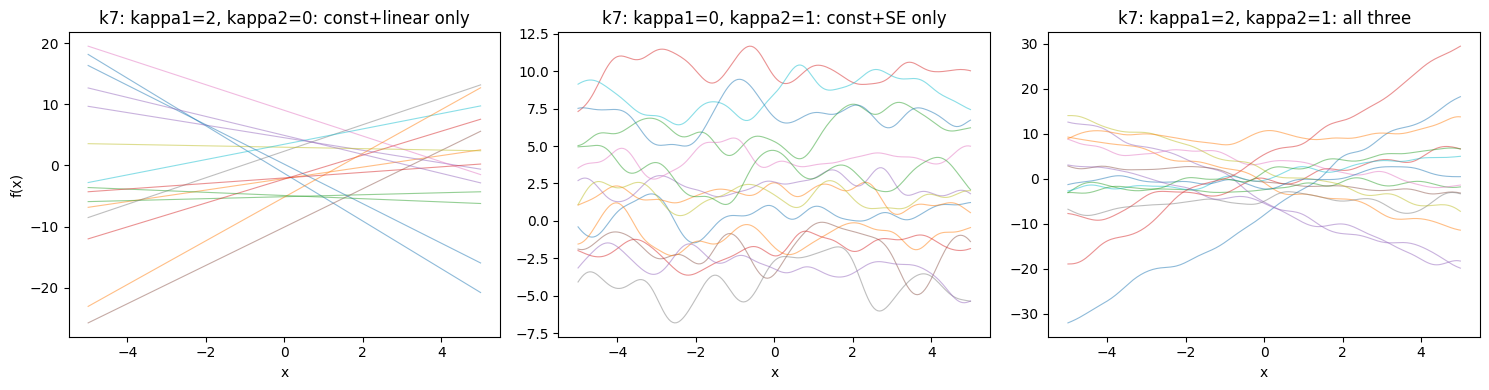

In [2]:
# KERNEL PRIOR VARIANCE — compute k(x,x) for any kernel
x_vals = np.array([0.0, 0.5, 1.0, 1.5, 2.0])

def k1(x, xp): return 2*np.exp(-(x-xp)**2/(2*0.3**2))
def k2(x, xp): return np.exp(-(x-xp)**2/(2*0.1**2))
def k3(x, xp): return 4 + 2*x*xp
def k4(x, xp): return np.exp(-2*np.sin(3*np.pi*np.abs(x-xp))**2)
def k5(x, xp): return np.exp(-2*np.sin(3*np.pi*np.abs(x-xp))**2) + 4*x*xp
def k6(x, xp): return 0.2 + np.minimum(x, xp)

kernels = [('k1', k1), ('k2', k2), ('k3', k3), ('k4', k4), ('k5', k5), ('k6', k6)]

print("Prior variance Var[f(x)] = k(x,x) at various x:")
print(f"{'Kernel':6s}  {'x=0':8s}  {'x=0.5':8s}  {'x=1':8s}  {'x=1.5':8s}  {'x=2':8s}  Stationary?")
for name, k in kernels:
    variances = [k(x, x) for x in x_vals]
    is_stationary = np.allclose(variances, variances[0])   # constant variance = stationary
    stat_str = 'Yes' if is_stationary else 'No (varies with x)'
    print(f"{name:6s}  " + "  ".join(f"{v:8.4f}" for v in variances) + f"  {stat_str}")
print()
print("Stationarity test: if Var[f(x)] varies with x -> NOT stationary")
print("(Constant variance is necessary but not sufficient for stationarity)")

# COMPOSITE KERNEL k7
def k7(x1, x2, kappa0, kappa1, kappa2, ell):
    dist_sq = (x1 - x2)**2
    return kappa0**2 + kappa1**2*x1*x2 + kappa2**2*np.exp(-dist_sq/(2*ell**2))

xp = np.linspace(-5, 5, 200)
configs = [(5,2,0,0.5,'kappa1=2, kappa2=0: const+linear only'),
           (5,0,1,0.5,'kappa1=0, kappa2=1: const+SE only'),
           (5,2,1,0.5,'kappa1=2, kappa2=1: all three')]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
np.random.seed(1)
for ax, (k0,k1_v,k2_v,ell,label) in zip(axes, configs):
    K = np.array([[k7(xi,xj,k0,k1_v,k2_v,ell) for xj in xp] for xi in xp])
    K += 1e-8*np.eye(len(xp))
    L = np.linalg.cholesky(K)
    samples = L @ np.random.randn(len(xp), 15)
    ax.plot(xp, samples, alpha=0.5, lw=0.8)
    ax.set(xlabel='x', title=f'k7: {label}')
axes[0].set_ylabel('f(x)')
plt.tight_layout(); plt.show()


---
## Part 2 — Non-linear Model + Laplace Approximation

### The model
$$f(x) = w_1\sigma(x + w_0), \quad p(y_n|x_n,w) = \mathcal{N}(y_n|f(x_n), \beta^{-1})$$
$$w_0, w_1 \sim \mathcal{N}(0, \tau^2) \text{ i.i.d.}$$

Hyperparameters: $\tau=2$, $\beta=4$ (so noise variance $= \beta^{-1} = 0.25$).

### Why can't you use the conjugate posterior formula?

The prior $p(w)$ is Gaussian and the likelihood $p(y|w)$ is Gaussian, **but the mean of the likelihood $f(x) = w_1\sigma(x+w_0)$ is non-linear in $w_0$**. The linear Gaussian formulas (Murphy Section 3.3) only work when the mean is linear in the parameters. Here it is not, so we must approximate.

### The 4-step workflow for non-linear models

<span style="color: blue;">
1. **Write log joint** = log prior + log likelihood
2. **Find MAP** via gradient ascent (or `scipy.optimize`)
3. **Compute Hessian** at MAP → **Laplace covariance** $\Sigma = -H^{-1}$
4. **Sample from Laplace** $q(w) = \mathcal{N}(\hat{w}_{\text{MAP}}, \Sigma)$ → MC estimates
</span>

### Log joint for this model
$$\log p(y,w) = -\frac{1}{2\tau^2}w_0^2 - \frac{1}{2\tau^2}w_1^2 - \frac{\beta}{2}\sum_{n=1}^N(y_n - f(x_n))^2 + \text{const}$$

### Gradient (for gradient ascent to find MAP)
$$\frac{\partial}{\partial w_0}\log p = -\frac{w_0}{\tau^2} + \beta\sum_n(y_n-f(x_n))\,w_1\,\sigma'(x_n+w_0)$$
$$\frac{\partial}{\partial w_1}\log p = -\frac{w_1}{\tau^2} + \beta\sum_n(y_n-f(x_n))\,\sigma(x_n+w_0)$$

**Pattern:** residual $(y_n-f_n)$ × derivative of $f$ w.r.t. that parameter.

### Hessian entries (evaluated at MAP for Laplace)
$$H_{11} = -\frac{1}{\tau^2} + \beta\sum_n\left[(y_n w_1 - w_1^2\sigma_n)\sigma''_n - (w_1\sigma'_n)^2\right]$$
$$H_{22} = -\frac{1}{\tau^2} - \beta\sum_n\sigma_n^2$$
$$H_{12} = \beta\sum_n(y_n - 2w_1\sigma_n)\sigma'_n$$

where $\sigma_n = \sigma(x_n+w_0)$, $\sigma'_n = \sigma'(x_n+w_0)$, $\sigma''_n = \sigma''(x_n+w_0)$.

In [3]:
# DATA
x_train = np.array([9.589, 7.375, 4.647, 2.501, 2.538, 6.783, 4.294, 5.111, 0.130, 0.783])
y_train = np.array([3.032, 3.349, 2.906, 2.126, 1.538, 2.787, 3.078, 2.993, 0.828,-0.331])

# HYPERPARAMETERS
tau  = 2.0
beta = 4.0

# MODEL
f_model = lambda x, w: w[1] * sigmoid(x + w[0])

# LOG JOINT
def log_joint_A2(w):
    f_n      = f_model(x_train, w)
    log_lik  = np.sum(log_npdf(y_train, f_n, 1/beta))
    log_pr   = log_npdf(w[0], 0, tau**2) + log_npdf(w[1], 0, tau**2)
    return log_lik + log_pr

print(f"log p(y, w=[0,0]) = {log_joint_A2(np.zeros(2)):.3f}  (expect -130.949)")

# GRADIENT (analytical)
def gradient_A2(w):
    f_n  = f_model(x_train, w)
    sig  = sigmoid(x_train + w[0])
    sigp = sigmoid_prime(x_train + w[0])
    resid = y_train - f_n
    g0 = -w[0]/tau**2 + beta * np.sum(resid * w[1] * sigp)
    g1 = -w[1]/tau**2 + beta * np.sum(resid * sig)
    return np.array([g0, g1])

# HESSIAN (analytical)
def hessian_A2(w):
    sig   = sigmoid(x_train + w[0])
    sigp  = sigmoid_prime(x_train + w[0])
    sigpp = sigmoid_pp(x_train + w[0])
    H11 = -1/tau**2 + beta*np.sum((y_train*w[1] - w[1]**2*sig)*sigpp - (w[1]*sigp)**2)
    H22 = -1/tau**2 - beta*np.sum(sig**2)
    H12 = beta*np.sum((y_train - 2*w[1]*sig)*sigp)
    return np.array([[H11,H12],[H12,H22]])

# FIND MAP via gradient ascent
w_MAP = np.zeros(2)
step  = 2e-2
for it in range(200):
    w_MAP = w_MAP + step * gradient_A2(w_MAP)

H_at_MAP = hessian_A2(w_MAP)
Sigma     = -np.linalg.inv(H_at_MAP)

print(f"w_MAP = {np.round(w_MAP, 3)}  (expect approx [-2.204, 3.104])")
print(f"Hessian H =\n{np.round(H_at_MAP, 3)}")
print(f"Laplace Sigma =\n{np.round(Sigma, 3)}")


log p(y, w=[0,0]) = -130.949  (expect -130.949)
w_MAP = [-2.204  3.104]  (expect approx [-2.204, 3.104])
Hessian H =
[[ -7.854  -6.897]
 [ -6.897 -25.143]]
Laplace Sigma =
[[ 0.168 -0.046]
 [-0.046  0.052]]


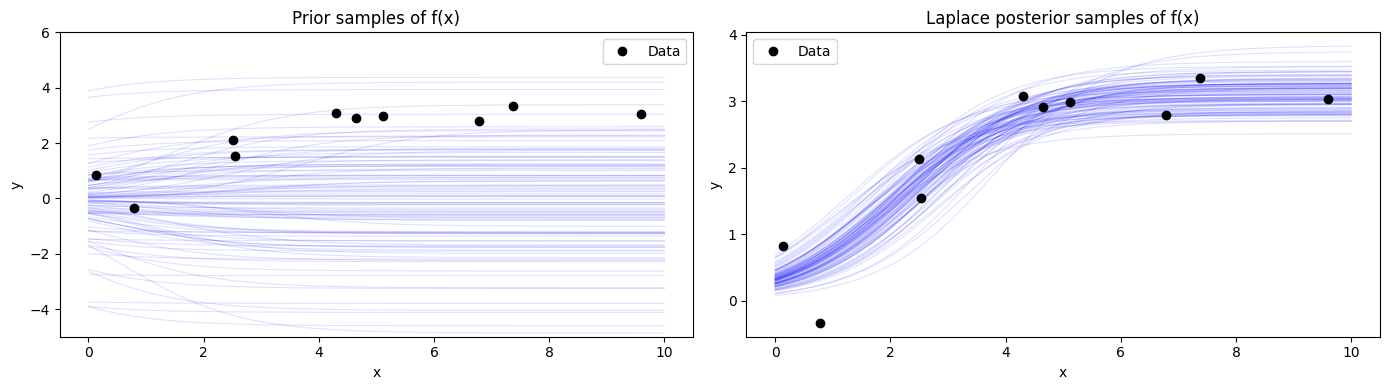

In [4]:
# PRIOR SAMPLES vs DATA
xpred = np.linspace(0, 10, 300)
np.random.seed(1)
w_prior = np.random.multivariate_normal(np.zeros(2), tau**2*np.eye(2), 100)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for wi in w_prior:
    axes[0].plot(xpred, f_model(xpred, wi), 'b-', alpha=0.12, lw=0.8)
axes[0].plot(x_train, y_train, 'ko', label='Data', zorder=5)
axes[0].set(xlabel='x', ylabel='y', title='Prior samples of f(x)', ylim=(-5,6))
axes[0].legend()

# POSTERIOR (Laplace) SAMPLES
np.random.seed(2)
w_post = np.random.multivariate_normal(w_MAP, Sigma, 100)
for wi in w_post:
    axes[1].plot(xpred, f_model(xpred, wi), 'b-', alpha=0.12, lw=0.8)
axes[1].plot(x_train, y_train, 'ko', label='Data', zorder=5)
axes[1].set(xlabel='x', ylabel='y', title='Laplace posterior samples of f(x)')
axes[1].legend()
plt.tight_layout(); plt.show()


### MC estimates from Laplace samples

Once you have $\Sigma = -H^{-1}$ and $\hat{w}_{\text{MAP}}$, all MC tasks follow the same pattern:

<span style="color: blue;">
1. Draw $w^{(i)} \sim \mathcal{N}(\hat{w}_{\text{MAP}}, \Sigma)$
2. Compute $f^{*(i)} = f(x^*, w^{(i)})$
3. For $y^*$: draw $y^{*(i)} = f^{*(i)} + \epsilon^{(i)}$, $\epsilon^{(i)} \sim \mathcal{N}(0, \beta^{-1})$
4. Apply indicator / mean / percentile to $\{f^{*(i)}\}$ or $\{y^{*(i)}\}$
</span>

In [5]:
# MC ESTIMATES FROM LAPLACE POSTERIOR
np.random.seed(42)
S = 10_000
w_samples = np.random.multivariate_normal(w_MAP, Sigma, S)

# Task 2.8: p(f(8) > 3 | y)
f8_samples = f_model(8.0, w_samples.T)   # shape (S,)
prob_f8    = np.mean(f8_samples > 3)
mcse_f8    = np.sqrt(np.var(f8_samples > 3) / S)
print(f"p(f(8) > 3 | y) = {prob_f8:.3f}  (MCSE = {mcse_f8:.3f})  [expect ~0.660]")

# Task 2.9: posterior predictive p(y*|y, x*=3.75)
x_star = 3.75
f_star = f_model(x_star, w_samples.T)
y_star = f_star + np.random.normal(0, np.sqrt(1/beta), S)

y_mean = np.mean(y_star)
y_lo, y_hi = np.percentile(y_star, [2.5, 97.5])
print(f"p(y*|y, x*={x_star}): mean = {y_mean:.2f},  95% CI = [{y_lo:.2f}, {y_hi:.2f}]")
print(f"  [expect: mean ~2.55, CI ~[1.46, 3.64]]")


p(f(8) > 3 | y) = 0.665  (MCSE = 0.005)  [expect ~0.660]
p(y*|y, x*=3.75): mean = 2.52,  95% CI = [1.49, 3.56]
  [expect: mean ~2.55, CI ~[1.46, 3.64]]


---
## Summary — What is new in Assignment 2

### Part 1 — GP kernels
| Question type | What you do |
|---|---|
| *"Compute prior variance"* | $\text{Var}[f(x)] = k(x,x)$ — set $x'=x$, all distance terms become 0 |
| *"Is kernel stationary?"* | Check if $k(x,x')$ can be written as $k(\tau)$ with $\tau=x-x'$ only. $xx'$ terms break this. |
| *"Match kernel to plot"* | Check: constant/varying variance, smooth/wiggly, periodic, linear trend |

### Part 2 — Non-linear model
| Question type | What you do |
|---|---|
| *"Why can't you use Section 3.3?"* | Non-linear mean function → conjugate formulas require linearity |
| *"Log joint"* | log prior + log likelihood, written out explicitly |
| *"Gradient"* | $-w_i/\tau^2$ + $\beta \sum_n$ (residual) × (derivative of $f$ w.r.t. $w_i$) |
| *"Hessian"* | Differentiate gradient again — use $\sigma' = \sigma(1-\sigma)$ and $\sigma'' = (1-2\sigma)\sigma'$ |
| *"Laplace approximation"* | $q(w) = \mathcal{N}(\hat{w}_{\text{MAP}}, -H^{-1})$ |
| *"p(f(x*)>c | y)"* | Sample $w^{(i)}\sim q$, compute $f^{*(i)}$, take fraction where $f^{*(i)}>c$ |
| *"Posterior predictive mean/CI"* | Sample $w^{(i)}\sim q$, then $y^{*(i)}=f^{*(i)}+\epsilon^{(i)}$, take mean/percentiles |

### The Sigmoid derivative identities (memorise these)
$$\sigma'(x) = \sigma(x)(1-\sigma(x))$$
$$\sigma''(x) = (1-2\sigma(x))\sigma'(x)$$